# Monet2Photo CycleGAN

In [2]:
import torch
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(0)

### CUDA 체크

In [5]:
import torch
print(torch.__version__)  # PyTorch 버전 확인
print(torch.cuda.is_available())  # CUDA 사용 가능 여부 확인
print(torch.cuda.get_device_name(0))  # GPU 이름 확인


2.6.0+cu118
True
NVIDIA GeForce RTX 2060 SUPER


## Getting Started
라이브러리를 가져오고, 시각화 함수를 정의하고, 사전 훈련된 CycleGAN 체크포인트를 가져오는 것으로 시작합니다.

In [8]:
def show_tensor_images(image_tensor, num_images=25, size=(1, 28, 28)):
    '''
    Function for visualizing images: Given a tensor of images, number of images, and
    size per image, plots and prints the images in an uniform grid.
    '''
    image_tensor = (image_tensor + 1) / 2
    image_shifted = image_tensor
    image_unflat = image_shifted.detach().cpu().view(-1, *size)
    image_grid = make_grid(image_unflat[:num_images], nrow=5)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.show()


import glob
import random
import os
from torch.utils.data import Dataset
from PIL import Image

# Inspired by https://github.com/aitorzip/PyTorch-CycleGAN/blob/master/datasets.py
class ImageDataset(Dataset):
    def __init__(self, root, transform=None, mode='train'):
        self.transform = transform
        self.files_A = sorted(glob.glob(os.path.join(root, '%sA' % mode) + '/*.*'))
        self.files_B = sorted(glob.glob(os.path.join(root, '%sB' % mode) + '/*.*'))
        if len(self.files_A) > len(self.files_B):
            self.files_A, self.files_B = self.files_B, self.files_A
        self.new_perm()
        assert len(self.files_A) > 0, "Make sure you downloaded the horse2zebra images!"

    def new_perm(self):
        self.randperm = torch.randperm(len(self.files_B))[:len(self.files_A)]

    def __getitem__(self, index):
        item_A = self.transform(Image.open(self.files_A[index % len(self.files_A)]))
        item_B = self.transform(Image.open(self.files_B[self.randperm[index]]))
        if item_A.shape[0] != 3: 
            item_A = item_A.repeat(3, 1, 1)
        if item_B.shape[0] != 3: 
            item_B = item_B.repeat(3, 1, 1)
        if index == len(self) - 1:
            self.new_perm()
        # Old versions of PyTorch didn't support normalization for different-channeled images
        return (item_A - 0.5) * 2, (item_B - 0.5) * 2

    def __len__(self):
        return min(len(self.files_A), len(self.files_B))

## Generator

#### Residual Block



ResidualBlock: 간단하게 원래 이미지 -> 훈련 -> Convolution Layer -> 변환성공
의 흐름을 따르는데, 훈련 다음에 원래 이미지를 한번 더 학습시켜서 원래 이미지의 특성을 유지시켜주는 것

In [12]:
class ResidualBlock(nn.Module):
    '''
    ResidualBlock Class:
    Performs two convolutions and an instance normalization, the input is added
    to this output to form the residual block output.
    Values:
        input_channels: the number of channels to expect from a given input
    '''
    def __init__(self, input_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, padding_mode='reflect')
        self.conv2 = nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, padding_mode='reflect')
        self.instancenorm = nn.InstanceNorm2d(input_channels) 
        # Norm2d의 변형버전 InstanceNorm2d 
        # 정규화 방법. 우리가 기존에 했던 BatchNorm과는 조금 다름
        # BatchNorm: batch 단위로 평균과 분산을 처리 (일반적 CNN 사용) 
        # InstanceNorm: 각 채널 별 개별 이미지에 대해 평균과 분산으로 처리 (GAN에서 사용 - 개별 스타일 이미지의 특성 보존을 위해)
        self.activation = nn.ReLU()

    def forward(self, x):
        '''
        Function for completing a forward pass of ResidualBlock: 
        Given an image tensor, completes a residual block and returns the transformed tensor.
        Parameters:
            x: image tensor of shape (batch size, channels, height, width)
        '''
        original_x = x.clone() # x값이 들어오면 일단 카피
        x = self.conv1(x)
        x = self.instancenorm(x) # nomalization
        x = self.activation(x)
        x = self.conv2(x)
        x = self.instancenorm(x)
        return original_x + x #원래 입력값 + conV된 값을 합쳐줌 - ResidualBlock

#### Contracting and Expanding Blocks

#### 블록 축소 및 확장


In [15]:
class ContractingBlock(nn.Module):
    '''
    ContractingBlock Class
    Performs a convolution followed by a max pool operation and an optional instance norm.
    Values:
        input_channels: the number of channels to expect from a given input
    '''
    
    # Conv2d를 통해 채널 수 확장 (width, height 축소)
    # input_channels -> input_channels * 2
    def __init__(self, input_channels, use_bn=True, kernel_size=3, activation='relu'):
        super(ContractingBlock, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, input_channels * 2, kernel_size=kernel_size, padding=1, stride=2, padding_mode='reflect')
        self.activation = nn.ReLU() if activation == 'relu' else nn.LeakyReLU(0.2)
        if use_bn:
            self.instancenorm = nn.InstanceNorm2d(input_channels * 2)
        self.use_bn = use_bn

    def forward(self, x):
        '''
        Function for completing a forward pass of ContractingBlock: 
        Given an image tensor, completes a contracting block and returns the transformed tensor.
        Parameters:
            x: image tensor of shape (batch size, channels, height, width)
        '''
        x = self.conv1(x)
        if self.use_bn:
            x = self.instancenorm(x)
        x = self.activation(x)
        return x

class ExpandingBlock(nn.Module):
    '''
    ExpandingBlock Class:
    Performs a convolutional transpose operation in order to upsample, 
        with an optional instance norm
    Values:
        input_channels: the number of channels to expect from a given input
    '''
    # Conv2dTranspose를 통해 채널 수 축소 (width, height 확장)
    # input_channels -> input_channels // 2
    def __init__(self, input_channels, use_bn=True):
        super(ExpandingBlock, self).__init__()
        self.conv1 = nn.ConvTranspose2d(input_channels, input_channels // 2, kernel_size=3, stride=2, padding=1, output_padding=1)
        if use_bn:
            self.instancenorm = nn.InstanceNorm2d(input_channels // 2)
        self.use_bn = use_bn
        self.activation = nn.ReLU()

    def forward(self, x):
        '''
        Function for completing a forward pass of ExpandingBlock: 
        Given an image tensor, completes an expanding block and returns the transformed tensor.
        Parameters:
            x: image tensor of shape (batch size, channels, height, width)
            skip_con_x: the image tensor from the contracting path (from the opposing block of x)
                    for the skip connection
        '''
        x = self.conv1(x)
        if self.use_bn:
            x = self.instancenorm(x)
        x = self.activation(x)
        return x

    # 압축 -> 확장 이후 정리하는 단계로 FeatureMapBlock 이용
    # 보통 Conv, Normalization, Activation(ReLU) 으로 이루어져있음.
class FeatureMapBlock(nn.Module):
    '''
    FeatureMapBlock Class
    The final layer of a Generator - 
    maps each the output to the desired number of output channels
    Values:
        input_channels: the number of channels to expect from a given input
        output_channels: the number of channels to expect for a given output
    '''
    def __init__(self, input_channels, output_channels):
        super(FeatureMapBlock, self).__init__()
        self.conv = nn.Conv2d(input_channels, output_channels, kernel_size=7, padding=3, padding_mode='reflect')

    def forward(self, x):
        '''
        Function for completing a forward pass of FeatureMapBlock: 
        Given an image tensor, returns it mapped to the desired number of channels.
        Parameters:
            x: image tensor of shape (batch size, channels, height, width)
        '''
        x = self.conv(x)
        return x

#### CycleGAN Generator
마지막으로 모든 블록을 모아서 CycleGAN 생성기를 만들 수 있습니다.


In [18]:
class Generator(nn.Module):
    '''
    Generator Class
    A series of 2 contracting blocks, 9 residual blocks, and 2 expanding blocks to 
    transform an input image into an image from the other class, with an upfeature
    layer at the start and a downfeature layer at the end.
    Values:
        input_channels: the number of channels to expect from a given input
        output_channels: the number of channels to expect for a given output
    '''
    def __init__(self, input_channels, output_channels, hidden_channels=64):
        super(Generator, self).__init__()
        self.upfeature = FeatureMapBlock(input_channels, hidden_channels)
        # why contract 2번?: 2번정도만 축소해도 충분하다고 함.
        self.contract1 = ContractingBlock(hidden_channels)
        self.contract2 = ContractingBlock(hidden_channels * 2)
        res_mult = 4
        self.res0 = ResidualBlock(hidden_channels * res_mult)
        self.res1 = ResidualBlock(hidden_channels * res_mult)
        self.res2 = ResidualBlock(hidden_channels * res_mult)
        self.res3 = ResidualBlock(hidden_channels * res_mult)
        self.res4 = ResidualBlock(hidden_channels * res_mult)
        self.res5 = ResidualBlock(hidden_channels * res_mult)
        self.res6 = ResidualBlock(hidden_channels * res_mult)
        self.res7 = ResidualBlock(hidden_channels * res_mult)
        self.res8 = ResidualBlock(hidden_channels * res_mult)
        self.expand2 = ExpandingBlock(hidden_channels * 4)
        self.expand3 = ExpandingBlock(hidden_channels * 2)
        self.downfeature = FeatureMapBlock(hidden_channels, output_channels)
        self.tanh = torch.nn.Tanh()

        
    # 위에 정의된 순서대로 쭉 학습
    def forward(self, x):
        '''
        Function for completing a forward pass of Generator: 
        Given an image tensor, passes it through the U-Net with residual blocks
        and returns the output.
        Parameters:
            x: image tensor of shape (batch size, channels, height, width)
        '''
        x0 = self.upfeature(x)
        x1 = self.contract1(x0)
        x2 = self.contract2(x1)
        x3 = self.res0(x2)
        x4 = self.res1(x3)
        x5 = self.res2(x4)
        x6 = self.res3(x5)
        x7 = self.res4(x6)
        x8 = self.res5(x7)
        x9 = self.res6(x8)
        x10 = self.res7(x9)
        x11 = self.res8(x10)
        x12 = self.expand2(x11)
        x13 = self.expand3(x12)
        xn = self.downfeature(x13)
        return self.tanh(xn)
        
        

## PatchGAN Discriminator

다음으로 판별자인 PatchGAN을 정의합니다. Pix2Pix에서 본 것과 매우 유사합니다.


PatchGAN ?
-> 이미치 패치를 개별적으로 판단 후 평균을 구함

-> Ex. 256 x 256 이미지를 70x70으로 나누면, 여러개의 패치가 생김.
-> 그러면 각 패치에서 진짜/가짜 판별 후 모든 결과 평균을 내는 방식

-> 저해상도 이미지변환 (스타일변환)에 좋음. 

(일반 Discriminator는 전체 이미지를 하나의 확률로 출력하며, 고해상도 이미지 생성에 유리함)


In [21]:
class Discriminator(nn.Module):
    '''
    Discriminator Class
    Structured like the contracting path of the U-Net, the discriminator will
    output a matrix of values classifying corresponding portions of the image as real or fake. 
    Parameters:
        input_channels: the number of image input channels
        hidden_channels: the initial number of discriminator convolutional filters
    '''
    def __init__(self, input_channels, hidden_channels=64):
        super(Discriminator, self).__init__()
        self.upfeature = FeatureMapBlock(input_channels, hidden_channels)
        self.contract1 = ContractingBlock(hidden_channels, use_bn=False, kernel_size=4, activation='lrelu') #LeakyReLU 사용
        self.contract2 = ContractingBlock(hidden_channels * 2, kernel_size=4, activation='lrelu')
        self.contract3 = ContractingBlock(hidden_channels * 4, kernel_size=4, activation='lrelu')
        # self.contract3에서 나오는 채널 수 8개를 (kernel_size=1)을 통해 하나로 압축
        self.final = nn.Conv2d(hidden_channels * 8, 1, kernel_size=1)

    def forward(self, x):
        x0 = self.upfeature(x)
        x1 = self.contract1(x0)
        x2 = self.contract2(x1)
        x3 = self.contract3(x2)
        xn = self.final(x3)
        return xn

## Training Preparation

이제 훈련을 위해 모든 것을 결합할 수 있습니다! 매개변수를 정의하여 시작합니다.

* adv_criterion: GAN이 판별자를 얼마나 잘 속이고 판별자가 GAN을 얼마나 잘 포착하는지 추적하는 적대적 손실 함수
* recon_criterion: 이미지를 "재구성"하는 ground truth에 유사한 이미지를 보상하는 손실 함수
--------------------------------
* Adversarial Loss (adv_criterion)로 Generator가 더 진짜 같은 이미지를 생성하도록 유도합니다.
* MSELoss를 사용해 Discriminator의 예측 값과 목표 값(1 또는 0) 사이의 오차를 최소화합니다.


* Reconstruction Loss (recon_criterion)로 Generator가 정답 이미지와 최대한 비슷한 이미지를 생성하도록 학습합니다.
* L1Loss를 사용해 생성된 이미지와 실제 이미지 간의 픽셀 차이를 최소화합니다.
--------------------------------

* n_epochs: 훈련 시 전체 데이터 세트를 반복하는 횟수
* dim_A: 더미 A에 있는 이미지의 채널 수
* dim_B: 더미 B에 있는 이미지의 채널 수(시각화에서 이것은 현재 dim_A와 동일한 것으로 취급됨을 참고하십시오)
* display_step: 이미지를 표시/시각화하는 빈도
* batch_size: 정방향/역방향 패스당 이미지 수
* lr: 학습률
* target_shape: 입력 및 출력 이미지의 크기(픽셀 단위)
* load_shape: 단순 데이터 증대로 target_shape에 무작위로 자르기 전에 이미지를 로드할 데이터 세트의 크기
* device: 장치 유형

In [24]:
import torch.nn.functional as F

adv_criterion = nn.MSELoss() 
# 왜 binary cross entropy 안쓸까? : GAN의 안정성이 MSELoss가 더 좋아서 GAN의 변형에는 보통 얘를 사용
recon_criterion = nn.L1Loss() 

n_epochs = 20
dim_A = 3
dim_B = 3
display_step = 2000
batch_size = 1
lr = 0.0002
load_shape = 286
target_shape = 256
device = 'cuda'

그런 다음 일부 데이터 증대(예: 자르기 및 무작위 수평 뒤집기)를 도입하면서 데이터세트의 이미지를 로드합니다.


In [27]:
transform = transforms.Compose([
    transforms.Resize(load_shape),
    transforms.RandomCrop(target_shape), # 이미지의 랜덤한 부분을 자름 -> 이미지 크기 감소 + 데이터 증강 효과
    transforms.RandomHorizontalFlip(), # 이미지를 랜덤으로 좌우반전 -> 이미지를 다양하게 학습가능
    transforms.ToTensor(),
])

import torchvision
dataset = ImageDataset("monet2photo", transform=transform)

다음으로 생성기 및 판별기 및 optimizer를 초기화할 수 있습니다. CycleGAN의 경우 두 개의 GAN이 있으므로 두 개의 생성기와 두 개의 판별자가 있습니다:

*   Generator for horse to zebra (`gen_AB`)
*   Generator for zebra to horse (`gen_BA`)
*   Discriminator for horse (`disc_A`)
*   Discriminator for zebra (`disc_B`)

사전 훈련된 모델도 로드합니다.

In [65]:
# 사전훈련 모델 가져오기 (자료없음)
gen_AB = Generator(dim_A, dim_B).to(device)
gen_BA = Generator(dim_B, dim_A).to(device)
gen_opt = torch.optim.Adam(list(gen_AB.parameters()) + list(gen_BA.parameters()), lr=lr, betas=(0.5, 0.999))
disc_A = Discriminator(dim_A).to(device)
disc_A_opt = torch.optim.Adam(disc_A.parameters(), lr=lr, betas=(0.5, 0.999))
disc_B = Discriminator(dim_B).to(device)
disc_B_opt = torch.optim.Adam(disc_B.parameters(), lr=lr, betas=(0.5, 0.999))

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)

# Feel free to change pretrained to False if you're training the model from scratch

pretrained = True

# if pretrained:
#     pre_dict = torch.load('cycleGAN_100000.pth')
#     gen_AB.load_state_dict(pre_dict['gen_AB'])
#     gen_BA.load_state_dict(pre_dict['gen_BA'])
#     gen_opt.load_state_dict(pre_dict['gen_opt'])
#     disc_A.load_state_dict(pre_dict['disc_A'])
#     disc_A_opt.load_state_dict(pre_dict['disc_A_opt'])
#     disc_B.load_state_dict(pre_dict['disc_B'])
#     disc_B_opt.load_state_dict(pre_dict['disc_B_opt'])
# else:
gen_AB = gen_AB.apply(weights_init)
gen_BA = gen_BA.apply(weights_init)
disc_A = disc_A.apply(weights_init)
disc_B = disc_B.apply(weights_init)

## Discriminator Loss


In [68]:
# UNQ_C1 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: get_disc_loss
def get_disc_loss(real_X, fake_X, disc_X, adv_criterion):
    '''
    Return the loss of the discriminator given inputs.
    Parameters:
        real_X: the real images from pile X
        fake_X: the generated images of class X
        disc_X: the discriminator for class X; takes images and returns real/fake class X
            prediction matrices
        adv_criterion: the adversarial loss function; takes the discriminator 
            predictions and the target labels and returns a adversarial 
            loss (which you aim to minimize)
    '''
    # detach: 역전파가 Generator까지 전달되지 않게 Discriminator만 업데이트 되도록 설정
    # 가짜이미지 판별 (hat) + 0에 가깝게 예측하도록 유도
    disc_fake_X_hat =  disc_X(fake_X.detach())
    disc_fake_X_loss =  adv_criterion(disc_fake_X_hat, torch.zeros_like(disc_fake_X_hat))
    
    
    # 진짜이미지 판별 (hat) + 1에 가깝게 예측하도록 유도
    disc_real_X_hat = disc_X(real_X)
    disc_real_X_loss =  adv_criterion(disc_real_X_hat, torch.ones_like(disc_real_X_hat))
    
    disc_loss = (disc_fake_X_loss + disc_real_X_loss) / 2
    return disc_loss

In [70]:
# UNIT TEST
test_disc_X = lambda x: x * 97
test_real_X = torch.tensor(83.)
test_fake_X = torch.tensor(89.)
test_adv_criterion = lambda x, y: x * 79 + y * 73
assert torch.abs((get_disc_loss(test_real_X, test_fake_X, test_disc_X, test_adv_criterion)) - 659054.5000) < 1e-6
test_disc_X = lambda x: x.mean(0, keepdim=True)
test_adv_criterion = torch.nn.BCEWithLogitsLoss()
test_input = torch.ones(20, 10)
# If this runs, it's a pass - checks that the shapes are treated correctly
get_disc_loss(test_input, test_input, test_disc_X, test_adv_criterion)
print("Success!")

Success!


## Generator Loss
Pix2Pix에서 CycleGAN 아키텍처에 몇 가지 변경 사항이 있지만 CycleGAN의 가장 중요한 구별 특성은 생성기 손실입니다. 여러분은 그것을 여기에서 구현할 것입니다!

#### Adversarial Loss
구현하려는 생성기 손실의 첫 번째 구성 요소는 적대적 손실(adversarial loss)입니다. 이것은 다시 한번 과거에 구현한 GAN 손실과 매우 유사합니다. 주목해야 할 중요한 점은 이제 기준이 이진 교차 엔트로피 손실 또는 W-손실이 아닌 최소 제곱 손실(least squares loss)을 기반으로 한다는 것입니다.

In [74]:
# UNQ_C2 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: get_gen_adversarial_loss
def get_gen_adversarial_loss(real_X, disc_Y, gen_XY, adv_criterion):
    '''
    Return the adversarial loss of the generator given inputs
    (and the generated images for testing purposes).
    Parameters:
        real_X: the real images from pile X
        disc_Y: the discriminator for class Y; takes images and returns real/fake class Y
            prediction matrices
        gen_XY: the generator for class X to Y; takes images and returns the images 
            transformed to class Y
        adv_criterion: the adversarial loss function; takes the discriminator 
                  predictions and the target labels and returns a adversarial 
                  loss (which you aim to minimize)
    '''

    fake_Y =  gen_XY(real_X) # Generator가 real_X를 받아 Y 스타일의 이미지 생성(fake)
    disc_fake_Y_hat =  disc_Y(fake_Y) # Discriminaot가 진짜/가짜 확률 반환
    # torch.ones_like (목표): fake가 1이랑 얼마나 많이 차이가 나는지, 손실값 반환
    adversarial_loss =  adv_criterion(disc_fake_Y_hat, torch.ones_like(disc_fake_Y_hat))

    
    return adversarial_loss, fake_Y

In [76]:
# UNIT TEST
test_disc_Y = lambda x: x * 97
test_real_X = torch.tensor(83.)
test_gen_XY = lambda x: x * 89
test_adv_criterion = lambda x, y: x * 79 + y * 73
test_res = get_gen_adversarial_loss(test_real_X, test_disc_Y, test_gen_XY, test_adv_criterion)
assert torch.abs(test_res[0] - 56606652) < 1e-6
assert torch.abs(test_res[1] - 7387) < 1e-6
test_disc_Y = lambda x: x.mean(0, keepdim=True)
test_adv_criterion = torch.nn.BCEWithLogitsLoss()
test_input = torch.ones(20, 10)
# If this runs, it's a pass - checks that the shapes are treated correctly
get_gen_adversarial_loss(test_input, test_disc_Y, test_gen_XY, test_adv_criterion)
print("Success!")

Success!


#### Identity Loss
* 얼룩말 -> 말 변환기 -> 말 (굿)
* 말 -> 말 변환기 -> 말 하면 색변환이 일어남 (오류)
* 따라서 이를 방지하기 위해 설정해주는 loss값

In [79]:
# UNQ_C3 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: get_identity_loss
def get_identity_loss(real_X, gen_YX, identity_criterion):
    '''
    Return the identity loss of the generator given inputs
    (and the generated images for testing purposes).
    Parameters:
        real_X: the real images from pile X
        gen_YX: the generator for class Y to X; takes images and returns the images 
            transformed to class X
        identity_criterion: the identity loss function; takes the real images from X and
                        those images put through a Y->X generator and returns the identity 
                        loss (which you aim to minimize)
    '''
    identity_X =  gen_YX(real_X)
    identity_loss =  identity_criterion(identity_X, real_X)

    return identity_loss, identity_X

In [81]:
# UNIT TEST
test_real_X = torch.tensor(83.)
test_gen_YX = lambda x: x * 89
test_identity_criterion = lambda x, y: (x + y) * 73
test_res = get_identity_loss(test_real_X, test_gen_YX, test_identity_criterion)
assert torch.abs(test_res[0] - 545310) < 1e-6
assert torch.abs(test_res[1] - 7387) < 1e-6
print("Success!")

Success!


#### Cycle Consistency Loss
* 진짜 (얼룩말) -> fake 생성 (말) -> 역방향으로 생성 (얼룩말)
* 했을 때 초기 얼룩말과 생성된 얼룩말의 같은 정도가 어느정도인가? -> Cycle Consistency Loss

In [84]:
# UNQ_C4 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: get_cycle_consistency_loss
def get_cycle_consistency_loss(real_X, fake_Y, gen_YX, cycle_criterion):
    '''
    Return the cycle consistency loss of the generator given inputs
    (and the generated images for testing purposes).
    Parameters:
        real_X: the real images from pile X
        fake_Y: the generated images of class Y
        gen_YX: the generator for class Y to X; takes images and returns the images 
            transformed to class X
        cycle_criterion: the cycle consistency loss function; takes the real images from X and
                        those images put through a X->Y generator and then Y->X generator
                        and returns the cycle consistency loss (which you aim to minimize)
    '''
    #### START CODE HERE (~2 lines)####
    cycle_X =  gen_YX(fake_Y)
    cycle_loss =  cycle_criterion(cycle_X, real_X)
    #### END CODE HERE ####
    return cycle_loss, cycle_X

In [86]:
# UNIT TEST
test_real_X = torch.tensor(83.)
test_fake_Y = torch.tensor(97.)
test_gen_YX = lambda x: x * 89
test_cycle_criterion = lambda x, y: (x + y) * 73
test_res = get_cycle_consistency_loss(test_real_X, test_fake_Y, test_gen_YX, test_cycle_criterion)
assert torch.abs(test_res[1] - 8633) < 1e-6
assert torch.abs(test_res[0] - 636268) < 1e-6
print("Success!")

Success!


#### Generator Loss (Total)

* 위에서 했던 모든 loss들 합하기
* 양방향 학습을 위해 2번씩 (정방향 / 역방향)으로 학습
------
* CycleGAN은 Generator가 얼마나 잘 변환하고 있는지 총 3개의 손실함수를 통해 계산함.
* 1. Adv Loss: Generator가 생성한 이미지가 실제랑 얼마나 다른지
* 2. Identity Loss: 말 이미지를 말 변환기에 넣으면 원본 이미지랑 얼마나 다른지
* 3. Cycle-consistency Loss: 말 -> 얼룩말 -> 말 했을때 원본 이미지랑 얼마나 다른지




In [89]:
# UNQ_C5 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: get_gen_loss
def get_gen_loss(real_A, real_B, gen_AB, gen_BA, disc_A, disc_B, adv_criterion, identity_criterion, cycle_criterion, lambda_identity=0.1, lambda_cycle=10):
    '''
    Return the loss of the generator given inputs.
    Parameters:
        real_A: the real images from pile A
        real_B: the real images from pile B
        gen_AB: the generator for class A to B; takes images and returns the images 
            transformed to class B
        gen_BA: the generator for class B to A; takes images and returns the images 
            transformed to class A
        disc_A: the discriminator for class A; takes images and returns real/fake class A
            prediction matrices
        disc_B: the discriminator for class B; takes images and returns real/fake class B
            prediction matrices
        adv_criterion: the adversarial loss function; takes the discriminator 
            predictions and the true labels and returns a adversarial 
            loss (which you aim to minimize)
        identity_criterion: the reconstruction loss function used for identity loss
            and cycle consistency loss; takes two sets of images and returns
            their pixel differences (which you aim to minimize)
        cycle_criterion: the cycle consistency loss function; takes the real images from X and
            those images put through a X->Y generator and then Y->X generator
            and returns the cycle consistency loss (which you aim to minimize).
            Note that in practice, cycle_criterion == identity_criterion == L1 loss
        lambda_identity: the weight of the identity loss
        lambda_cycle: the weight of the cycle-consistency loss
    '''
    
    # Adversarial Loss -- get_gen_adversarial_loss(real_X, disc_Y, gen_XY, adv_criterion) (2 lines)
    adv_loss_AB, fake_B =  get_gen_adversarial_loss(real_A, disc_B, gen_AB, adv_criterion)
    adv_loss_BA, fake_A =  get_gen_adversarial_loss(real_B, disc_A, gen_BA, adv_criterion)
    gen_adversarial_loss = adv_loss_BA + adv_loss_AB

    # Identity Loss -- get_identity_loss(real_X, gen_YX, identity_criterion) (2 lines)
    identity_loss_A, identity_A =  get_identity_loss(real_A, gen_BA, identity_criterion)
    identity_loss_B, identity_B =  get_identity_loss(real_B, gen_AB, identity_criterion)
    gen_identity_loss = identity_loss_A + identity_loss_B

    # Cycle-consistency Loss -- get_cycle_consistency_loss(real_X, fake_Y, gen_YX, cycle_criterion) (2 lines)
    cycle_loss_BA, cycle_A =  get_cycle_consistency_loss(real_A, fake_B, gen_BA, cycle_criterion)
    cycle_loss_AB, cycle_B =  get_cycle_consistency_loss(real_B, fake_A, gen_AB, cycle_criterion)
    gen_cycle_loss = cycle_loss_BA + cycle_loss_AB

    # Total loss
    gen_loss = lambda_identity * gen_identity_loss + lambda_cycle * gen_cycle_loss + gen_adversarial_loss

    return gen_loss, fake_A, fake_B

In [91]:
# UNIT TEST
test_real_A = torch.tensor(97)
test_real_B = torch.tensor(89)
test_gen_AB = lambda x: x * 83
test_gen_BA = lambda x: x * 79
test_disc_A = lambda x: x * 47
test_disc_B = lambda x: x * 43
test_adv_criterion = lambda x, y: x * 73 + y * 71
test_recon_criterion = lambda x, y: (x + y) * 61
test_lambda_identity = 59
test_lambda_cycle = 53
test_res = get_gen_loss(
    test_real_A, 
    test_real_B, 
    test_gen_AB, 
    test_gen_BA, 
    test_disc_A,
    test_disc_B,
    test_adv_criterion, 
    test_recon_criterion, 
    test_recon_criterion, 
    test_lambda_identity, 
    test_lambda_cycle)
assert test_res[0].item() == 4047804560
assert test_res[1].item() == 7031
assert test_res[2].item() == 8051
print("Success!")

Success!


## CycleGAN Training

마지막으로, 모델을 훈련시키고 얼룩말, 말, 그리고 전혀 닮지 않은 얼룩말을 볼 수 있습니다! 이 훈련은 시간이 오래 걸리므로 사전 훈련된 체크포인트를 꽤 좋은 CycleGAN이 하는 일의 예로 자유롭게 사용하십시오.


Epoch 1/20:   0%|          | 0/1072 [00:00<?, ?it/s, Gen Loss=0.0040, Disc Loss=0.0001]

Epoch 0: Step 0: Generator (U-Net) loss: 0.0040446419715881345, Discriminator loss: 0.00010553377866744996


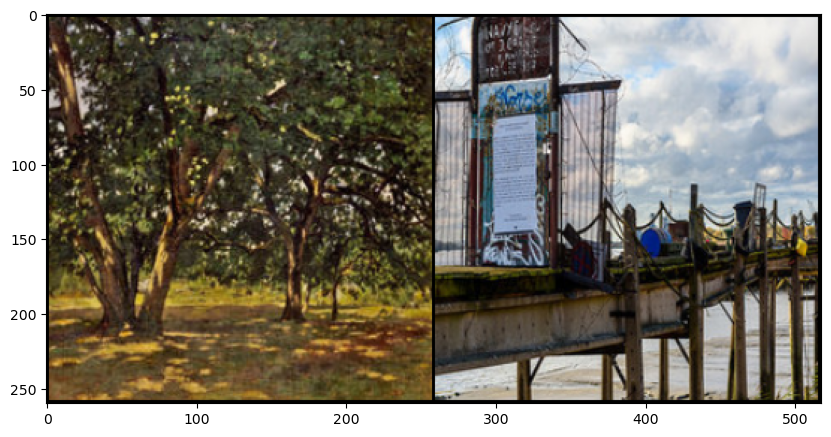

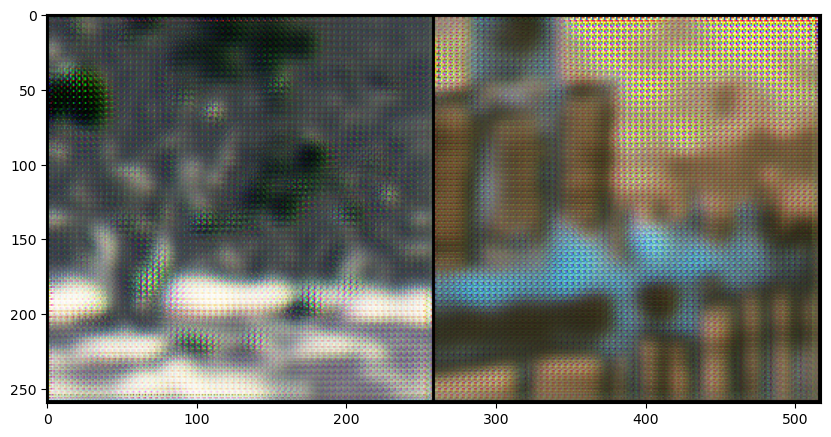

Epoch 2/20:  87%|████████▋ | 928/1072 [07:32<01:11,  2.00it/s, Gen Loss=6.1460, Disc Loss=0.2098]

Epoch 1: Step 2000: Generator (U-Net) loss: 6.146017902493474, Discriminator loss: 0.20983860977925387


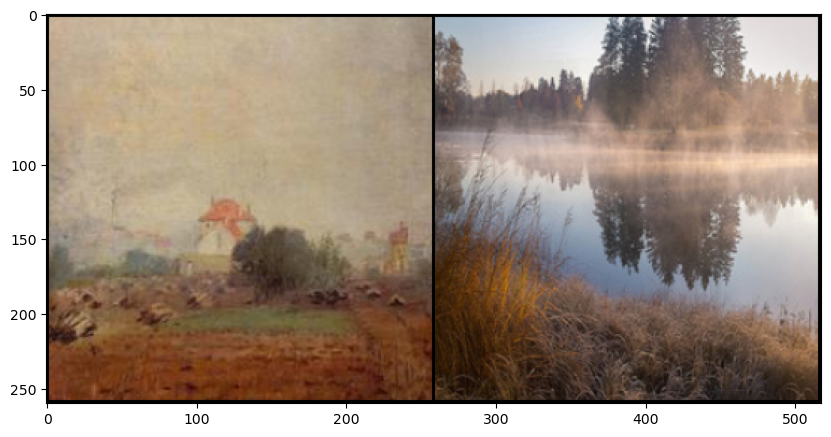

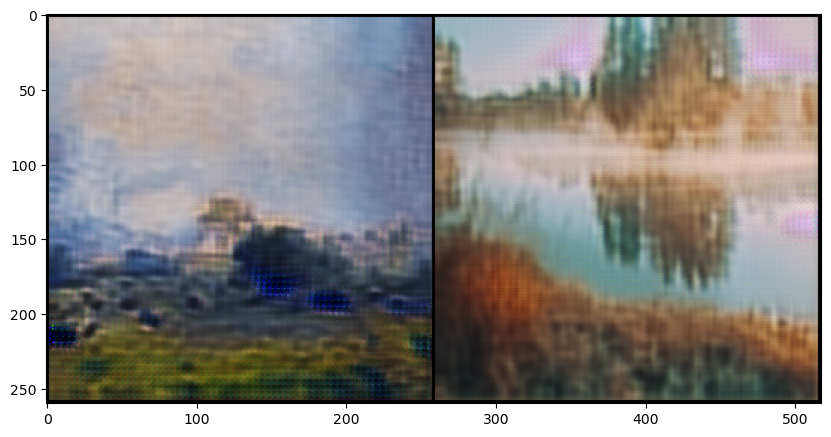

Epoch 4/20:  73%|███████▎  | 784/1072 [06:23<02:23,  2.00it/s, Gen Loss=5.1783, Disc Loss=0.2158]

Epoch 3: Step 4000: Generator (U-Net) loss: 5.17828657913208, Discriminator loss: 0.21580213808268328


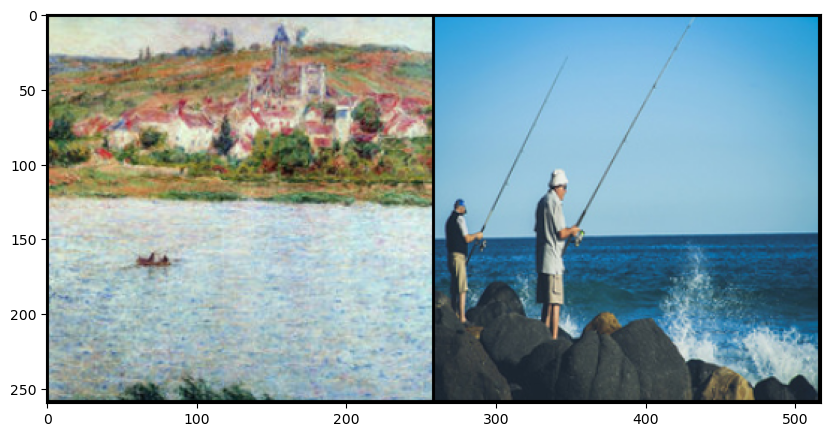

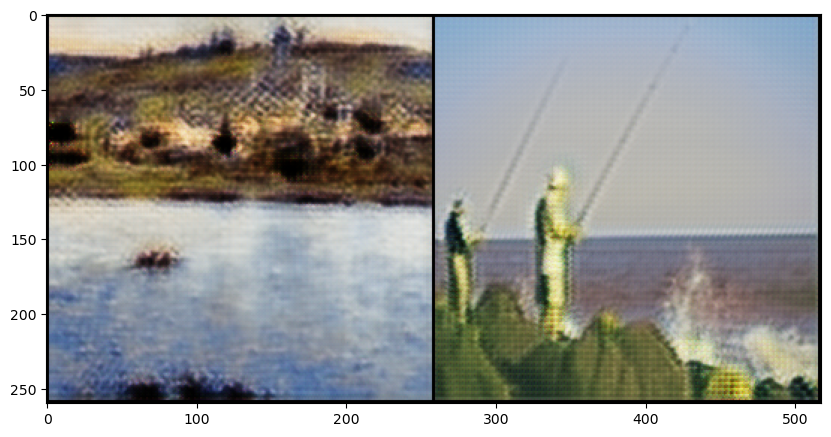

Epoch 6/20:  60%|█████▉    | 640/1072 [05:11<03:27,  2.08it/s, Gen Loss=4.8855, Disc Loss=0.2181]

Epoch 5: Step 6000: Generator (U-Net) loss: 4.885544856190671, Discriminator loss: 0.21814190971292574


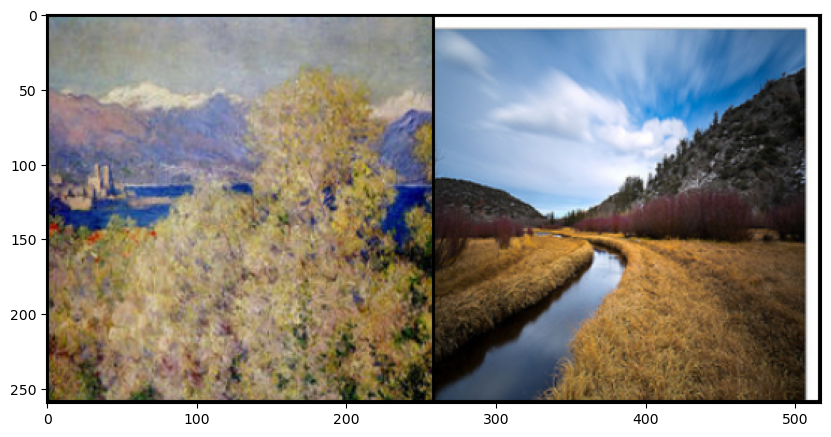

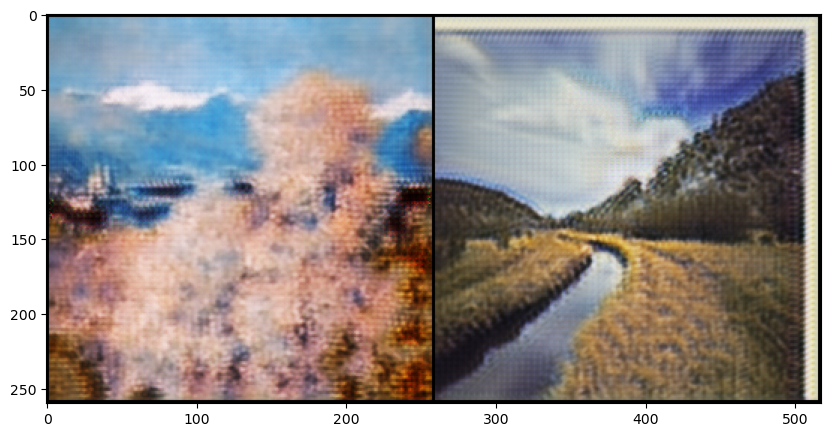

Epoch 8/20:  46%|████▋     | 496/1072 [04:00<04:39,  2.06it/s, Gen Loss=4.6391, Disc Loss=0.2144]

Epoch 7: Step 8000: Generator (U-Net) loss: 4.639069156289099, Discriminator loss: 0.21443048204481602


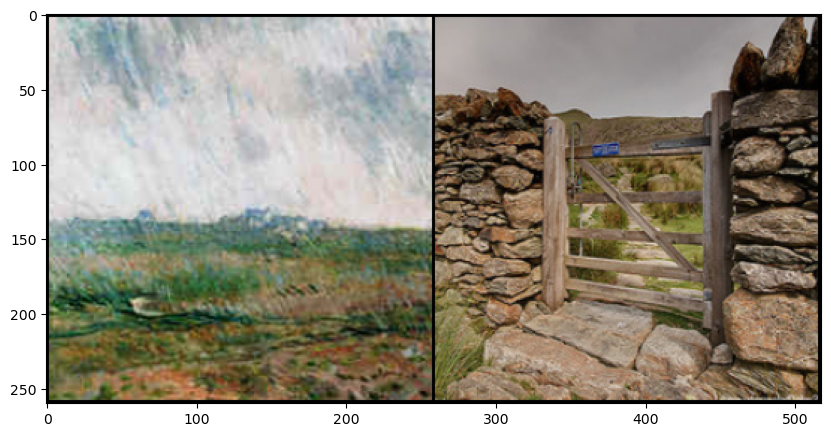

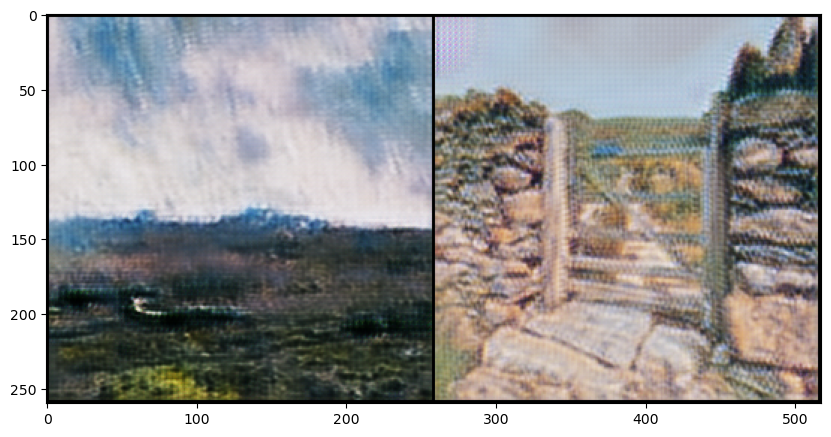

Epoch 10/20:  33%|███▎      | 352/1072 [02:52<05:48,  2.06it/s, Gen Loss=4.6192, Disc Loss=0.2148]

Epoch 9: Step 10000: Generator (U-Net) loss: 4.61922704029084, Discriminator loss: 0.21476760843023665


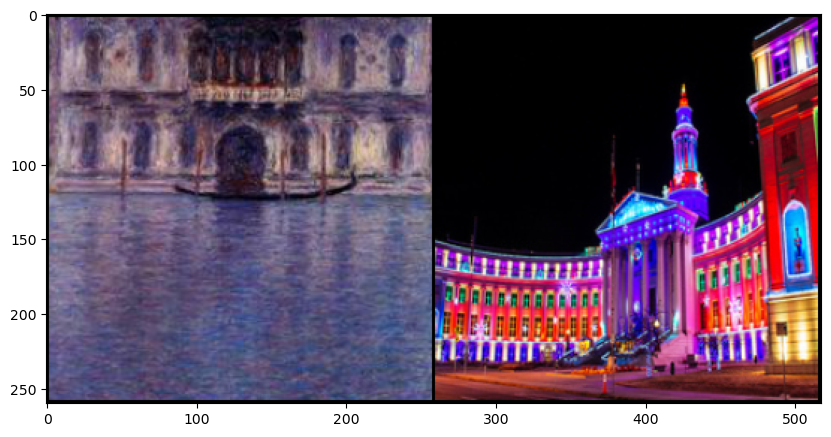

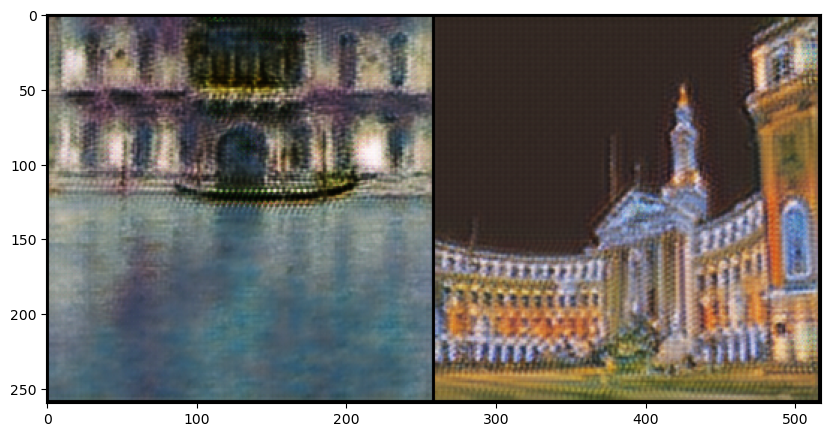

Epoch 10/20:  87%|████████▋ | 928/1072 [07:35<01:10,  2.04it/s, Gen Loss=4.6192, Disc Loss=0.2148]


KeyboardInterrupt: 

In [96]:
from tqdm import tqdm  # 이미 import 되어 있다면 생략
import torch

def train(save_model=True):
    mean_generator_loss = 0
    mean_discriminator_loss = 0
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    cur_step = 0

    for epoch in range(n_epochs):
        with tqdm(dataloader, desc=f"Epoch {epoch+1}/{n_epochs}", leave=True) as pbar:
            for real_A, real_B in pbar:
                real_A = nn.functional.interpolate(real_A, size=target_shape)
                real_B = nn.functional.interpolate(real_B, size=target_shape)
                cur_batch_size = len(real_A)

                real_A = real_A.to(device)
                real_B = real_B.to(device)

                ### Update discriminator A ###
                disc_A_opt.zero_grad()
                with torch.no_grad():
                    fake_A = gen_BA(real_B)
                disc_A_loss = get_disc_loss(real_A, fake_A, disc_A, adv_criterion)
                disc_A_loss.backward(retain_graph=True)
                disc_A_opt.step()

                ### Update discriminator B ###
                disc_B_opt.zero_grad()
                with torch.no_grad():
                    fake_B = gen_AB(real_A)
                disc_B_loss = get_disc_loss(real_B, fake_B, disc_B, adv_criterion)
                disc_B_loss.backward(retain_graph=True)
                disc_B_opt.step()

                ### Update generator ###
                gen_opt.zero_grad()
                gen_loss, fake_A, fake_B = get_gen_loss(
                    real_A, real_B, gen_AB, gen_BA, disc_A, disc_B, adv_criterion, recon_criterion, recon_criterion
                )
                gen_loss.backward()
                gen_opt.step()

                mean_discriminator_loss += disc_A_loss.item() / display_step
                mean_generator_loss += gen_loss.item() / display_step

                if cur_step % display_step == 0:
                    pbar.set_postfix({
                        "Gen Loss": f"{mean_generator_loss:.4f}",
                        "Disc Loss": f"{mean_discriminator_loss:.4f}"
                    })
                    print(f"Epoch {epoch}: Step {cur_step}: Generator (U-Net) loss: {mean_generator_loss}, Discriminator loss: {mean_discriminator_loss}")
                    show_tensor_images(torch.cat([real_A, real_B]), size=(dim_A, target_shape, target_shape))
                    show_tensor_images(torch.cat([fake_B, fake_A]), size=(dim_B, target_shape, target_shape))
                    mean_generator_loss = 0
                    mean_discriminator_loss = 0
                    if save_model:
                        torch.save({
                            'gen_AB': gen_AB.state_dict(),
                            'gen_BA': gen_BA.state_dict(),
                            'gen_opt': gen_opt.state_dict(),
                            'disc_A': disc_A.state_dict(),
                            'disc_A_opt': disc_A_opt.state_dict(),
                            'disc_B': disc_B.state_dict(),
                            'disc_B_opt': disc_B_opt.state_dict()
                        }, f"cycleGAN_{cur_step}.pth")
                cur_step += 1

train()
